<a href="https://colab.research.google.com/github/xIndRahardjo/BBCA_Stock_Prediction/blob/main/MLT_Yahoo_Finance_Final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install yfinance xgboost lightgbm

In [2]:
import yfinance as yf
import pandas as pd

#Change ticker ID to stock target
#Target ID can search in yahoo finance website
ticker = "QCOM"

#For download all dataset
#df = yf.download(ticker, period="max")

df = yf.download(ticker, start="2020-01-01", end ="2026-03-05")

if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.droplevel(1)
    df.columns.name = None


print("Downloaded stock data for:", ticker)
print("\nData shape:", df.shape)
print("\nFirst few rows:")
print(df.head())

# Save to CSV if needed
df.to_csv(f"{ticker}.csv")
print(f"\nData saved to {ticker}.csv")

/tmp/ipykernel_2760/2261978667.py:11: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start="2020-01-01", end ="2026-03-05")
[*********************100%***********************]  1 of 1 completed

Downloaded stock data for: QCOM

Data shape: (1550, 5)

First few rows:
                Close       High        Low       Open   Volume
Date                                                           
2020-01-02  77.151047  78.125326  76.620410  77.464210  8413900
2020-01-03  75.698296  76.237633  75.193761  75.907075  8340300
2020-01-06  75.254654  75.289451  74.410854  74.732718  8381400
2020-01-07  77.394608  77.846950  75.602625  75.715709  8377400
2020-01-08  77.168411  77.829534  76.481193  77.333693  7619900

Data saved to QCOM.csv


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import xgboost as xgb
import lightgbm as lgb
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Set style untuk visualisasi
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("="*80)
print("PROGRAM PREDIKSI HARGA SAHAM")
print("Model: Linear Regression, XGBoost, LightGBM")
print("="*80)

PROGRAM PREDIKSI HARGA SAHAM
Model: Linear Regression, XGBoost, LightGBM


##Preprocessing


[2] DATA PREPROCESSING...

Statistik Deskriptif Data Awal:
              Open         High          Low        Close        Volume
count  1550.000000  1550.000000  1550.000000  1550.000000  1.550000e+03
mean    131.084895   132.904851   129.203552   131.072705  9.066135e+06
std      30.183156    30.530482    29.765450    30.127569  4.644434e+06
min      53.590955    56.870252    50.855296    53.406830  1.645300e+06
25%     111.807724   113.580001   110.394889   111.958242  6.440675e+06
50%     130.003637   131.749122   127.992729   129.795074  7.918000e+06
75%     155.346152   157.177635   152.953662   155.347843  1.020720e+07
max     218.163975   221.828573   217.375261   218.423660  8.179930e+07

Membuat indikator teknikal...
✓ Indikator teknikal berhasil dihitung
  - SMA (5, 15, 30 hari)
  - EMA (9 hari)
  - RSI (14 periode)
  - MACD & Signal

Baris dengan NaN dihapus: 29 baris
Data tersisa: 1521 baris

Membuat visualisasi indikator teknikal secara terpisah...


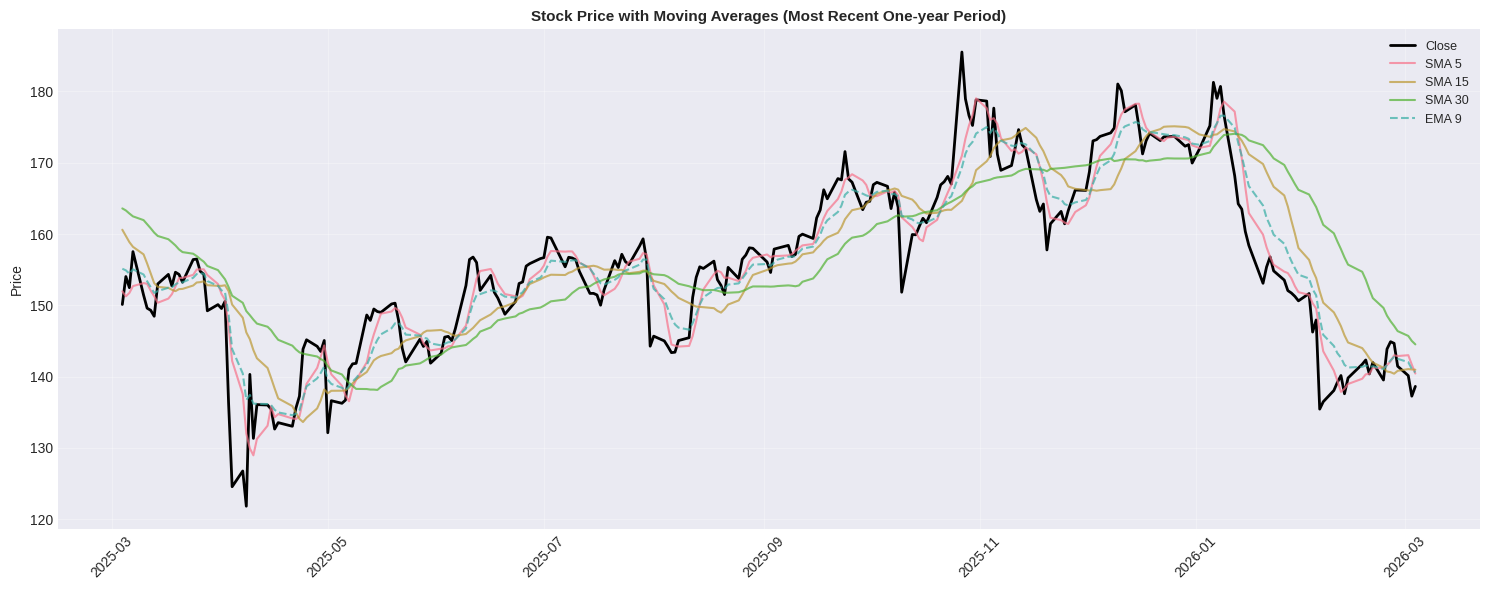

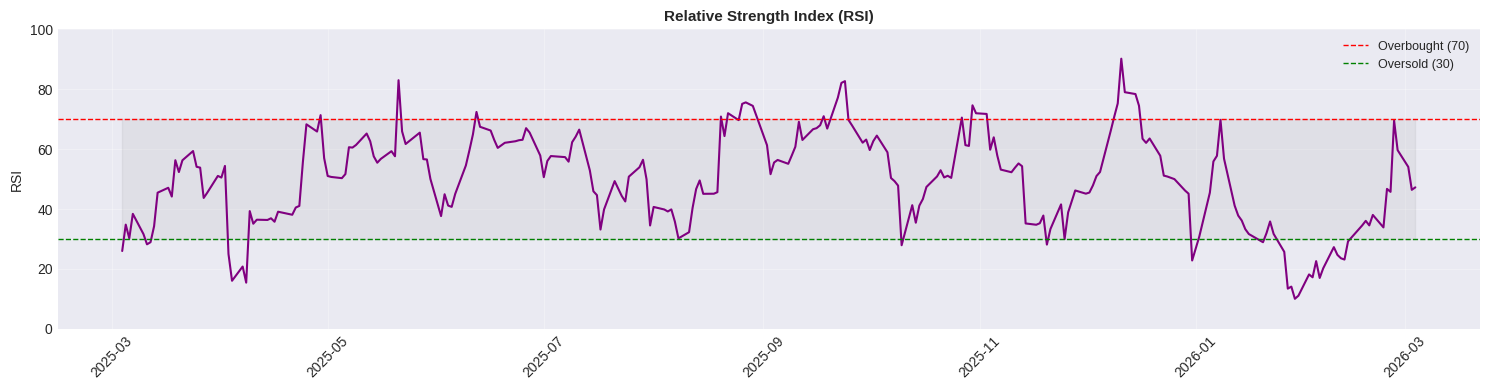

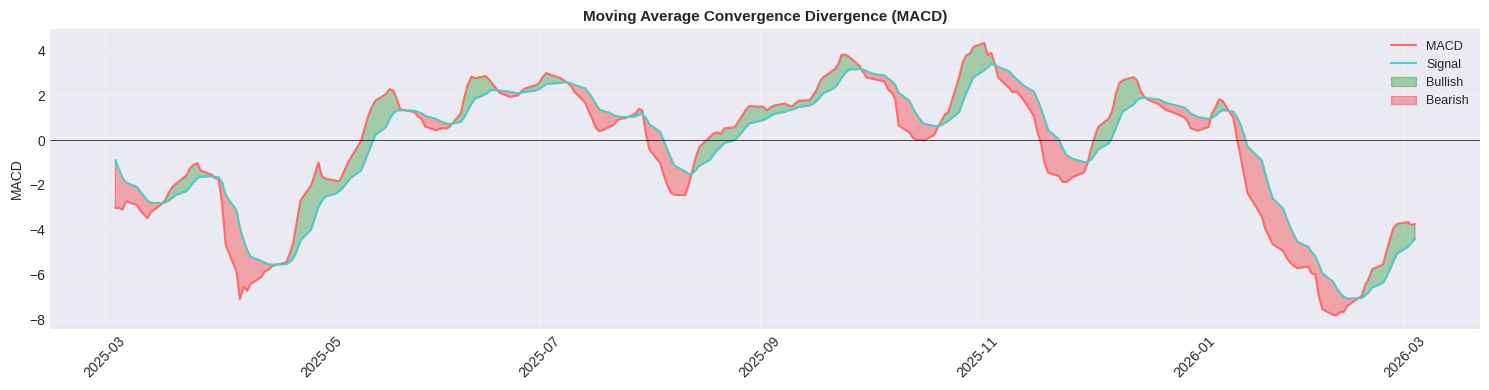

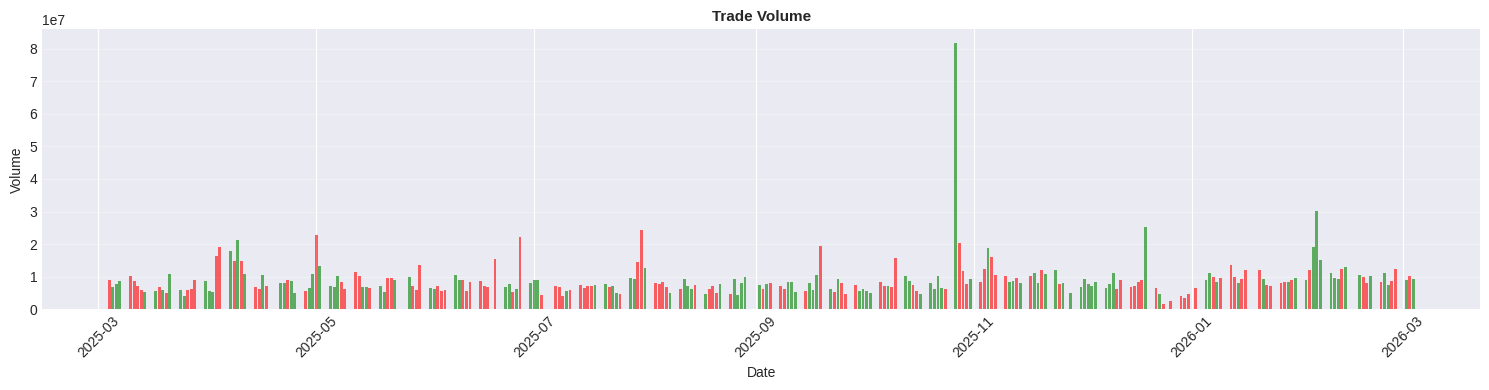


FITUR UNTUK PREDIKSI:
 1. Open
 2. High
 3. Low
 4. Volume
 5. SMA_5
 6. SMA_15
 7. SMA_30
 8. EMA_9
 9. RSI
10. MACD
11. MACD_Signal

Mendeteksi outliers...


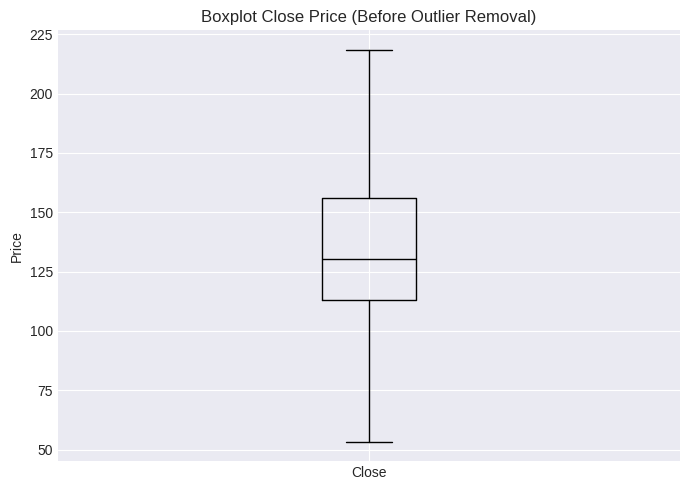

  Close: Lower=49.20, Upper=219.82
         Outliers terdeteksi: 0

✓ Total outliers dihapus: 0 baris (0.00%)
✓ Data bersih tersisa: 1521 baris


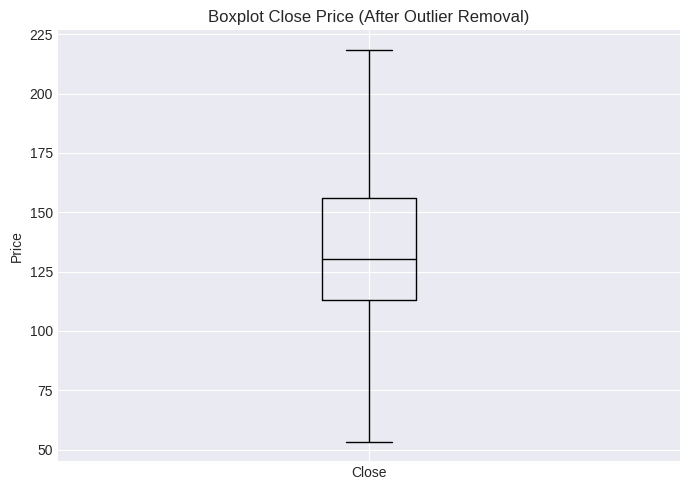


Membuat heatmap korelasi...


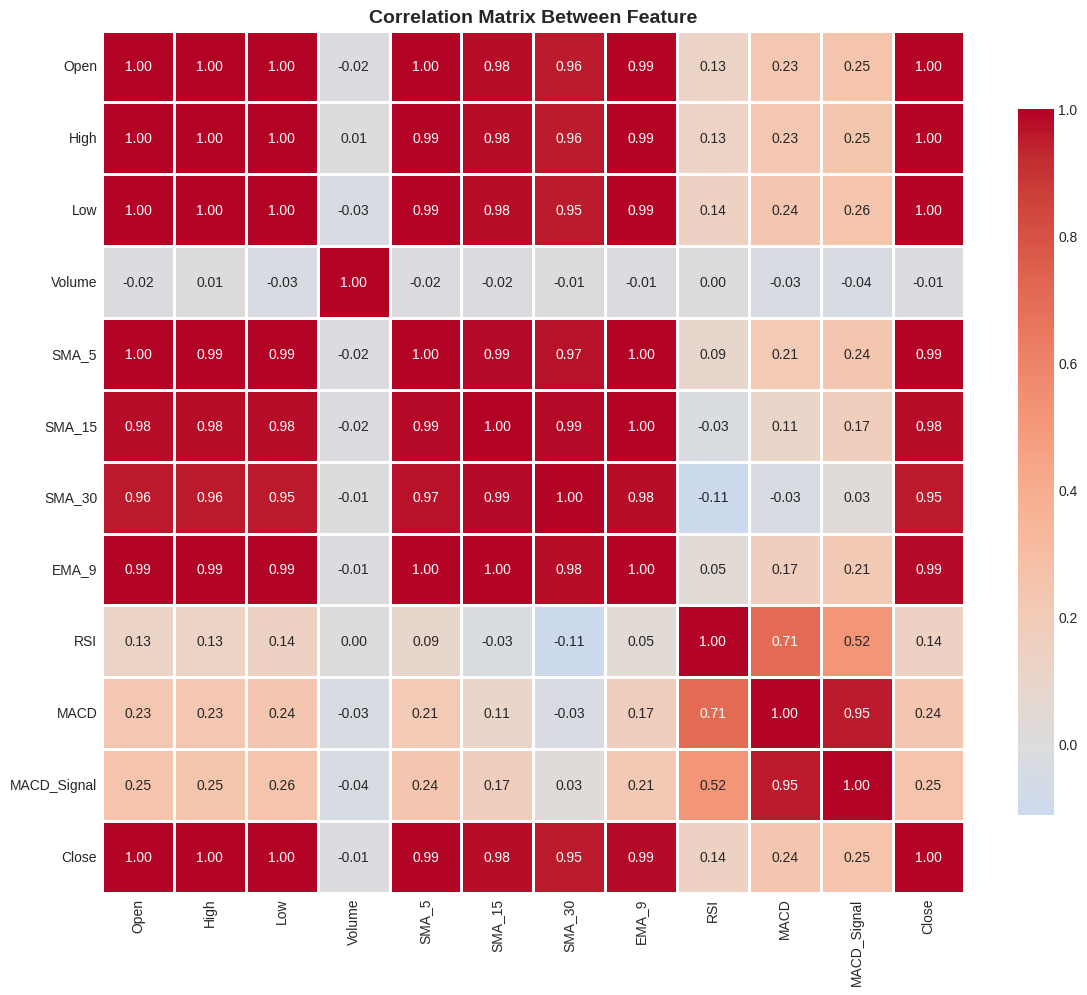


Korelasi dengan Harga Close:
  Low            :  0.998
  High           :  0.998
  Open           :  0.996
  SMA_5          :  0.993
  EMA_9          :  0.991
  SMA_15         :  0.978
  SMA_30         :  0.954
  MACD_Signal    :  0.250
  MACD           :  0.236
  RSI            :  0.142
  Volume         : -0.014

PREPROCESSING SELESAI!


In [4]:
print("\n[2] DATA PREPROCESSING...")

# Reset the index to make 'Date' a regular column again
df = df.reset_index()

# Convert Date ke datetime (this might be redundant if the index was already datetime,
# but it ensures the column is of datetime type if reset_index changed its dtype)
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date').reset_index(drop=True)

# Simpan kolom Date untuk visualisasi
df_dates = df['Date'].copy()

# Statistik deskriptif data awal
print("\nStatistik Deskriptif Data Awal:")
print(df[['Open', 'High', 'Low', 'Close', 'Volume']].describe())

# Membuat fitur teknikal berdasarkan jurnal (Jange, 2022)
print("\nMembuat indikator teknikal...")

def calculate_sma(data, window):
    """Simple Moving Average"""
    return data.rolling(window=window).mean()

def calculate_ema(data, span):
    """Exponential Moving Average"""
    return data.ewm(span=span, adjust=False).mean()

def calculate_rsi(data, period=14):
    """Relative Strength Index"""
    delta = data.diff()
    gain = (delta.where(delta > 0, 0)).rolling(window=period).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window=period).mean()
    rs = gain / loss
    rsi = 100 - (100 / (1 + rs))
    return rsi

def calculate_macd(data, fast=12, slow=26, signal=9):
    """Moving Average Convergence Divergence"""
    ema_fast = data.ewm(span=fast, adjust=False).mean()
    ema_slow = data.ewm(span=slow, adjust=False).mean()
    macd = ema_fast - ema_slow
    macd_signal = macd.ewm(span=signal, adjust=False).mean()
    return macd, macd_signal

# Hitung indikator teknikal
df['SMA_5'] = calculate_sma(df['Close'], 5)
df['SMA_15'] = calculate_sma(df['Close'], 15)
df['SMA_30'] = calculate_sma(df['Close'], 30)
df['EMA_9'] = calculate_ema(df['Close'], 9)
df['RSI'] = calculate_rsi(df['Close'])
df['MACD'], df['MACD_Signal'] = calculate_macd(df['Close'])

print("✓ Indikator teknikal berhasil dihitung")
print(f"  - SMA (5, 15, 30 hari)")
print(f"  - EMA (9 hari)")
print(f"  - RSI (14 periode)")
print(f"  - MACD & Signal")

# Hapus baris dengan NaN
rows_before = len(df)
df = df.dropna().reset_index(drop=True)
print(f"\nBaris dengan NaN dihapus: {rows_before - len(df)} baris")
print(f"Data tersisa: {len(df)} baris")

# Visualisasi indikator teknikal
print("\nMembuat visualisasi indikator teknikal secara terpisah...")

# Ambil data 1 tahun terakhir untuk visualisasi
plot_range = slice(-252, None)  # 1 tahun terakhir
date_range = df['Date'].iloc[plot_range]

# Plot 1: Harga Close dengan SMA dan EMA
plt.figure(figsize=(15, 6))
plt.plot(date_range, df['Close'].iloc[plot_range],
         label='Close', linewidth=2, color='black')
plt.plot(date_range, df['SMA_5'].iloc[plot_range],
         label='SMA 5', linewidth=1.5, alpha=0.7)
plt.plot(date_range, df['SMA_15'].iloc[plot_range],
         label='SMA 15', linewidth=1.5, alpha=0.7)
plt.plot(date_range, df['SMA_30'].iloc[plot_range],
         label='SMA 30', linewidth=1.5, alpha=0.7)
plt.plot(date_range, df['EMA_9'].iloc[plot_range],
         label='EMA 9', linewidth=1.5, linestyle='--', alpha=0.7)
plt.ylabel('Price', fontsize=10)
plt.title('Stock Price with Moving Averages (Most Recent One-year Period)',
          fontsize=11, fontweight='bold')
plt.legend(loc='best', fontsize=9)
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(f'{ticker}_stock_price_ma.eps', format='eps')
plt.show()

# Plot 2: RSI
plt.figure(figsize=(15, 4))
plt.plot(date_range, df['RSI'].iloc[plot_range],
         linewidth=1.5, color='purple')
plt.axhline(y=70, color='r', linestyle='--', label='Overbought (70)', linewidth=1)
plt.axhline(y=30, color='g', linestyle='--', label='Oversold (30)', linewidth=1)
plt.fill_between(date_range, 30, 70, alpha=0.1, color='gray')
plt.ylabel('RSI', fontsize=10)
plt.title('Relative Strength Index (RSI)', fontsize=11, fontweight='bold')
plt.legend(loc='best', fontsize=9)
plt.grid(True, alpha=0.3)
plt.ylim([0, 100])
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(f'{ticker}_rsi_indicator.eps', format='eps')
plt.show()

# Plot 3: MACD
plt.figure(figsize=(15, 4))
plt.plot(date_range, df['MACD'].iloc[plot_range],
         label='MACD', linewidth=1.5, color='#FF6B6B')
plt.plot(date_range, df['MACD_Signal'].iloc[plot_range],
         label='Signal', linewidth=1.5, color='#4ECDC4')
plt.axhline(y=0, color='black', linestyle='-', linewidth=0.5)

# Fill area untuk bullish dan bearish
macd_data = df['MACD'].iloc[plot_range].values
signal_data = df['MACD_Signal'].iloc[plot_range].values
plt.fill_between(date_range, macd_data, signal_data,
                 where=(macd_data >= signal_data),
                 color='green', alpha=0.3, label='Bullish', interpolate=True)
plt.fill_between(date_range, macd_data, signal_data,
                 where=(macd_data < signal_data),
                 color='red', alpha=0.3, label='Bearish', interpolate=True)

plt.ylabel('MACD', fontsize=10)
plt.title('Moving Average Convergence Divergence (MACD)',
          fontsize=11, fontweight='bold')
plt.legend(loc='best', fontsize=9)
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(f'{ticker}_macd_indicator.eps', format='eps')
plt.show()

# Plot 4: Volume
plt.figure(figsize=(15, 4))
colors = ['green' if df['Close'].iloc[i] >= df['Open'].iloc[i]
          else 'red' for i in df.iloc[plot_range].index]
plt.bar(date_range, df['Volume'].iloc[plot_range],
        color=colors, alpha=0.6, width=0.8)
plt.ylabel('Volume', fontsize=10)
plt.xlabel('Date', fontsize=10)
plt.title('Trade Volume', fontsize=11, fontweight='bold')
plt.grid(True, alpha=0.3, axis='y')
plt.xticks(rotation=45)

# Format angka pada axis y untuk volume
plt.ticklabel_format(style='scientific', axis='y', scilimits=(0,0))

plt.tight_layout()
plt.savefig(f'{ticker}_trade_volume.eps', format='eps')
plt.show()

# Fitur yang digunakan
print("\n" + "="*60)
print("FITUR UNTUK PREDIKSI:")
print("="*60)
feature_cols = ['Open', 'High', 'Low', 'Volume', 'SMA_5', 'SMA_15',
                'SMA_30', 'EMA_9', 'RSI', 'MACD', 'MACD_Signal']
for i, feat in enumerate(feature_cols, 1):
    print(f"{i:2d}. {feat}")
print("="*60)

# Deteksi dan handling outliers (berdasarkan Andrika, 2025)
print("\nMendeteksi outliers...")

# Visualisasi boxplot sebelum menghapus outliers
plt.figure(figsize=(7, 5))
df.boxplot(column=['Close'], color='black')
plt.title('Boxplot Close Price (Before Outlier Removal)')
plt.ylabel('Price')
plt.tight_layout()
plt.savefig(f'{ticker}_boxplot_before_outlier_removal.eps', format='eps')
plt.show()

def remove_outliers(df, columns):
    """Remove outliers menggunakan IQR method"""
    df_clean = df.copy()
    outlier_indices = set()

    for col in columns:
        Q1 = df_clean[col].quantile(0.25)
        Q3 = df_clean[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        # Simpan indeks outlier
        outlier_idx = df_clean[(df_clean[col] < lower_bound) |
                              (df_clean[col] > upper_bound)].index
        outlier_indices.update(outlier_idx)

        print(f"  {col}: Lower={lower_bound:.2f}, Upper={upper_bound:.2f}")
        print(f"         Outliers terdeteksi: {len(outlier_idx)}")

    # Hapus semua outlier
    df_clean = df_clean.drop(index=list(outlier_indices))
    df_clean = df_clean.reset_index(drop=True)

    return df_clean

df_original_len = len(df)
df = remove_outliers(df, ['Close'])
outliers_removed = df_original_len - len(df)

print(f"\n✓ Total outliers dihapus: {outliers_removed} baris ({outliers_removed/df_original_len*100:.2f}%)")
print(f"✓ Data bersih tersisa: {len(df)} baris")

# Boxplot setelah menghapus outliers
plt.figure(figsize=(7, 5))
df.boxplot(column=['Close'], color='black')
plt.title('Boxplot Close Price (After Outlier Removal)')
plt.ylabel('Price')
plt.tight_layout()
plt.savefig(f'{ticker}_boxplot_after_outlier_removal.eps', format='eps')
plt.show()

# Korelasi antar fitur
print("\nMembuat heatmap korelasi...")
correlation_matrix = df[feature_cols + ['Close']].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Correlation Matrix Between Feature', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{ticker}_correlation_heatmap.eps', format='eps') # Save the plot as eps
plt.show()

# Tampilkan korelasi tertinggi dengan Close
print("\nKorelasi dengan Harga Close:")
close_corr = correlation_matrix['Close'].sort_values(ascending=False)
for feat, corr in close_corr.items():
    if feat != 'Close':
        print(f"  {feat:15s}: {corr:6.3f}")

print("\n" + "="*60)
print("PREPROCESSING SELESAI!")
print("="*60)

In [5]:
print("\n[3] SPLITTING DATA...")

# Fitur dan target
X = df[feature_cols]
y = df['Close']

# Split 80:20 (berdasarkan Andrika, 2025)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, shuffle=False
)

print(f"Training set: {len(X_train)} samples")
print(f"Testing set: {len(X_test)} samples")

# Normalisasi data menggunakan MinMaxScaler
print("\nNormalisasi data...")
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)



[3] SPLITTING DATA...
Training set: 1216 samples
Testing set: 305 samples

Normalisasi data...


##LinearBase

In [6]:
import time

print("\n[4] MODEL TRAINING...")

results = {}

# ---------------------------------------------------------------------------
# 5.1 LINEAR REGRESSION
# ---------------------------------------------------------------------------
print("\n--- Linear Regression ---")
lr_model = LinearRegression()

# Record training time
start_time_train = time.time()
lr_model.fit(X_train_scaled, y_train)
lr_train_time = time.time() - start_time_train

# Record prediction time
start_time_pred = time.time()
y_pred_lr = lr_model.predict(X_test_scaled)
lr_predict_time = time.time() - start_time_pred

# Evaluasi
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
mae_lr = mean_absolute_error(y_test, y_pred_lr)
mape_lr = np.mean(np.abs((y_test - y_pred_lr) / y_test)) * 100
r2_lr = r2_score(y_test, y_pred_lr)

results['Linear Regression'] = {
    'model': lr_model,
    'predictions': y_pred_lr,
    'RMSE': rmse_lr,
    'MAE': mae_lr,
    'MAPE': mape_lr,
    'R2': r2_lr,
    'Train Time': lr_train_time,
    'Prediction Time': lr_predict_time
}

print(f"RMSE: {rmse_lr:.4f}")
print(f"MAE: {mae_lr:.4f}")
print(f"MAPE: {mape_lr:.4f}%")
print(f"R²: {r2_lr:.4f}")
print(f"Train Time: {lr_train_time:.4f} seconds")
print(f"Prediction Time: {lr_predict_time:.4f} seconds")


[4] MODEL TRAINING...

--- Linear Regression ---
RMSE: 1.0361
MAE: 0.7695
MAPE: 0.4938%
R²: 0.9922
Train Time: 0.0202 seconds
Prediction Time: 0.0004 seconds


##GridSearch

In [7]:
import time

# ---------------------------------------------------------------------------
# 5.2 XGBOOST (berdasarkan Jange, 2022 & Zhang, 2022)
# ---------------------------------------------------------------------------
print("\n--- XGBoost ---")

# Hyperparameter tuning menggunakan GridSearchCV
xgb_params = {
    'n_estimators': [100, 200, 400],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 8, 12],
    'gamma': [0.001, 0.01]
}

print("Melakukan Grid Search untuk hyperparameter tuning...")
xgb_model = xgb.XGBRegressor(random_state=42, objective='reg:squarederror')
xgb_grid = GridSearchCV(xgb_model, xgb_params, cv=3,
                        scoring='neg_root_mean_squared_error',
                        n_jobs=-1, verbose=0)

# Record training time for GridSearchCV
start_time_train_xgb = time.time()
xgb_grid.fit(X_train_scaled, y_train)
xgb_train_time = time.time() - start_time_train_xgb

print(f"Best parameters: {xgb_grid.best_params_}")
best_xgb_params_from_grid = xgb_grid.best_params_

# Record prediction time
start_time_pred_xgb = time.time()
y_pred_xgb = xgb_grid.best_estimator_.predict(X_test_scaled)
xgb_predict_time = time.time() - start_time_pred_xgb

# Evaluasi
rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
mape_xgb = np.mean(np.abs((y_test - y_pred_xgb) / y_test)) * 100
r2_xgb = r2_score(y_test, y_pred_xgb)

results['XGBoost'] = {
    'model': xgb_grid.best_estimator_,
    'predictions': y_pred_xgb,
    'RMSE': rmse_xgb,
    'MAE': mae_xgb,
    'MAPE': mape_xgb,
    'R2': r2_xgb,
    'Train Time': xgb_train_time,
    'Prediction Time': xgb_predict_time
}

print(f"RMSE: {rmse_xgb:.4f}")
print(f"MAE: {mae_xgb:.4f}")
print(f"MAPE: {mape_xgb:.4f}%")
print(f"R²: {r2_xgb:.4f}")
print(f"Train Time: {xgb_train_time:.4f} seconds")
print(f"Prediction Time: {xgb_predict_time:.4f} seconds")


--- XGBoost ---
Melakukan Grid Search untuk hyperparameter tuning...
Best parameters: {'gamma': 0.01, 'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 400}
RMSE: 1.7694
MAE: 1.3489
MAPE: 0.8599%
R²: 0.9773
Train Time: 98.4418 seconds
Prediction Time: 0.0025 seconds


In [8]:
import time

print("\n--- LightGBM ---")

# Hyperparameter tuning
lgb_params = {
    'n_estimators': [100, 200, 400],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 8, 12],
    'num_leaves': [31, 50, 70],
    'boosting_type': ['gbdt', 'dart']
}

print("Melakukan Grid Search untuk hyperparameter tuning...")
lgb_model = lgb.LGBMRegressor(random_state=42, verbose=-1)
lgb_grid = GridSearchCV(lgb_model, lgb_params, cv=3,
                        scoring='neg_root_mean_squared_error',
                        n_jobs=-1, verbose=0)

# Record training time for GridSearchCV
start_time_train_lgb = time.time()
lgb_grid.fit(X_train_scaled, y_train)
lgb_train_time = time.time() - start_time_train_lgb

print(f"Best parameters: {lgb_grid.best_params_}")
best_lgb_params_from_grid = lgb_grid.best_params_

# Record prediction time
start_time_pred_lgb = time.time()
y_pred_lgb = lgb_grid.best_estimator_.predict(X_test_scaled)
lgb_predict_time = time.time() - start_time_pred_lgb

# Evaluasi
rmse_lgb = np.sqrt(mean_squared_error(y_test, y_pred_lgb))
mae_lgb = mean_absolute_error(y_test, y_pred_lgb)
mape_lgb = np.mean(np.abs((y_test - y_pred_lgb) / y_test)) * 100
r2_lgb = r2_score(y_test, y_pred_lgb)

results['LightGBM'] = {
    'model': lgb_grid.best_estimator_,
    'predictions': y_pred_lgb,
    'RMSE': rmse_lgb,
    'MAE': mae_lgb,
    'MAPE': mape_lgb,
    'R2': r2_lgb,
    'Train Time': lgb_train_time,
    'Prediction Time': lgb_predict_time
}

print(f"RMSE: {rmse_lgb:.4f}")
print(f"MAE: {mae_lgb:.4f}")
print(f"MAPE: {mape_lgb:.4f}%")
print(f"R²: {r2_lgb:.4f}")
print(f"Train Time: {lgb_train_time:.4f} seconds")
print(f"Prediction Time: {lgb_predict_time:.4f} seconds")


--- LightGBM ---
Melakukan Grid Search untuk hyperparameter tuning...
Best parameters: {'boosting_type': 'gbdt', 'learning_rate': 0.05, 'max_depth': 8, 'n_estimators': 400, 'num_leaves': 50}
RMSE: 1.8207
MAE: 1.3001
MAPE: 0.8266%
R²: 0.9760
Train Time: 87.1521 seconds
Prediction Time: 0.0079 seconds


##Fixed Param Boosting

In [9]:
import time

print('\n--- XGBoost with Fixed Best Parameters ---')

# Best parameters obtained from previous GridSearchCV for XGBoost
# Dynamically updated to use best_xgb_params_from_grid
best_xgb_params = best_xgb_params_from_grid

# Initialize and train XGBoost model with fixed parameters
fixed_xgb_model = xgb.XGBRegressor(random_state=42, objective='reg:squarederror', **best_xgb_params)

# Record training time
start_time_train_xgb_fixed = time.time()
fixed_xgb_model.fit(X_train_scaled, y_train)
xgb_fixed_train_time = time.time() - start_time_train_xgb_fixed

# Make predictions and record prediction time
start_time_pred_xgb_fixed = time.time()
y_pred_fixed_xgb = fixed_xgb_model.predict(X_test_scaled)
xgb_fixed_predict_time = time.time() - start_time_pred_xgb_fixed

# Evaluate
rmse_fixed_xgb = np.sqrt(mean_squared_error(y_test, y_pred_fixed_xgb))
mae_fixed_xgb = mean_absolute_error(y_test, y_pred_fixed_xgb)
mape_fixed_xgb = np.mean(np.abs((y_test - y_pred_fixed_xgb) / y_test)) * 100
r2_fixed_xgb = r2_score(y_test, y_pred_fixed_xgb)

results['XGBoost (Fixed Params)'] = {
    'model': fixed_xgb_model,
    'predictions': y_pred_fixed_xgb,
    'RMSE': rmse_fixed_xgb,
    'MAE': mae_fixed_xgb,
    'MAPE': mape_fixed_xgb,
    'R2': r2_fixed_xgb,
    'Train Time': xgb_fixed_train_time,
    'Prediction Time': xgb_fixed_predict_time
}

print(f"RMSE: {rmse_fixed_xgb:.4f}")
print(f"MAE: {mae_fixed_xgb:.4f}")
print(f"MAPE: {mape_fixed_xgb:.4f}%")
print(f"R²: {r2_fixed_xgb:.4f}")
print(f"Train Time: {xgb_fixed_train_time:.4f} seconds")
print(f"Prediction Time: {xgb_fixed_predict_time:.4f} seconds")


--- XGBoost with Fixed Best Parameters ---
RMSE: 1.7694
MAE: 1.3489
MAPE: 0.8599%
R²: 0.9773
Train Time: 0.2435 seconds
Prediction Time: 0.0024 seconds


In [10]:
print('\n--- LightGBM with Fixed Best Parameters ---')

# Best parameters obtained from previous GridSearchCV for LightGBM
best_lgb_params = best_lgb_params_from_grid

# Initialize and train LightGBM model with fixed parameters
fixed_lgb_model = lgb.LGBMRegressor(random_state=42, verbose=-1, **best_lgb_params)

# Record training time
start_time_train_lgb_fixed = time.time()
fixed_lgb_model.fit(X_train_scaled, y_train)
lgb_fixed_train_time = time.time() - start_time_train_lgb_fixed

# Make predictions and record prediction time
start_time_pred_lgb_fixed = time.time()
y_pred_fixed_lgb = fixed_lgb_model.predict(X_test_scaled)
lgb_fixed_predict_time = time.time() - start_time_pred_lgb_fixed

# Evaluate
rmse_fixed_lgb = np.sqrt(mean_squared_error(y_test, y_pred_fixed_lgb))
mae_fixed_lgb = mean_absolute_error(y_test, y_pred_fixed_lgb)
mape_fixed_lgb = np.mean(np.abs((y_test - y_pred_fixed_lgb) / y_test)) * 100
r2_fixed_lgb = r2_score(y_test, y_pred_fixed_lgb)

results['LightGBM (Fixed Params)'] = {
    'model': fixed_lgb_model,
    'predictions': y_pred_fixed_lgb,
    'RMSE': rmse_fixed_lgb,
    'MAE': mae_fixed_lgb,
    'MAPE': mape_fixed_lgb,
    'R2': r2_fixed_lgb,
    'Train Time': lgb_fixed_train_time,
    'Prediction Time': lgb_fixed_predict_time
}

print(f"RMSE: {rmse_fixed_lgb:.4f}")
print(f"MAE: {mae_fixed_lgb:.4f}")
print(f"MAPE: {mape_fixed_lgb:.4f}%")
print(f"R²: {r2_fixed_lgb:.4f}")
print(f"Train Time: {lgb_fixed_train_time:.4f} seconds")
print(f"Prediction Time: {lgb_fixed_predict_time:.4f} seconds")


--- LightGBM with Fixed Best Parameters ---
RMSE: 1.8207
MAE: 1.3001
MAPE: 0.8266%
R²: 0.9760
Train Time: 0.2180 seconds
Prediction Time: 0.0081 seconds


##Result


PERBANDINGAN HASIL MODEL

            Model     RMSE      MAE  MAPE (%)       R²  Train Time (s)  Prediction Time (s)
Linear Regression 1.036143 0.769468  0.493819 0.992220        0.020180             0.000408
          XGBoost 1.769356 1.348869  0.859860 0.977313       98.441824             0.002452
         LightGBM 1.820742 1.300113  0.826581 0.975976       87.152127             0.007913

MODEL TERBAIK: Linear Regression
   (Berdasarkan RMSE terendah)

[5] MEMBUAT VISUALISASI...


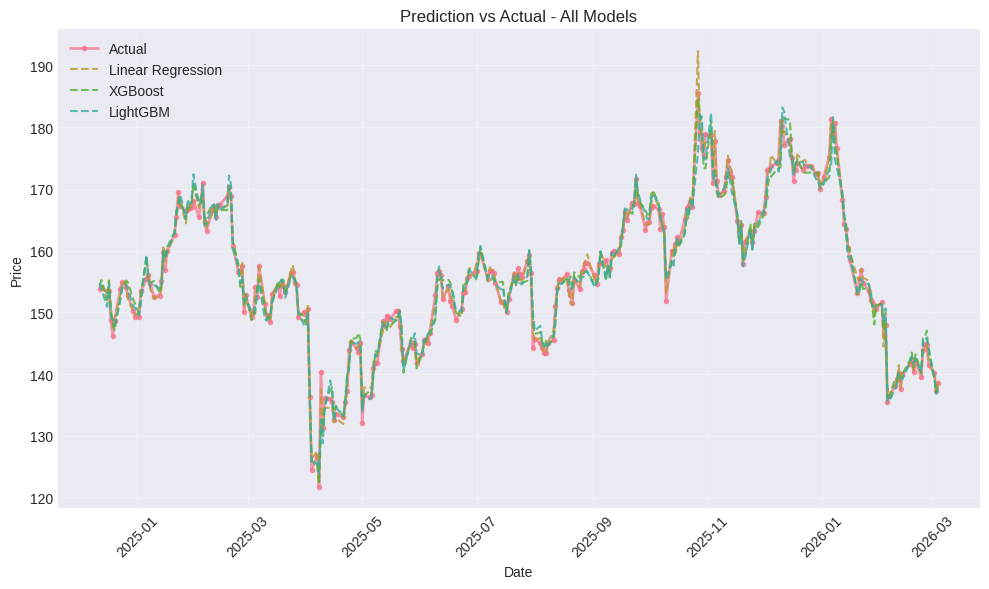

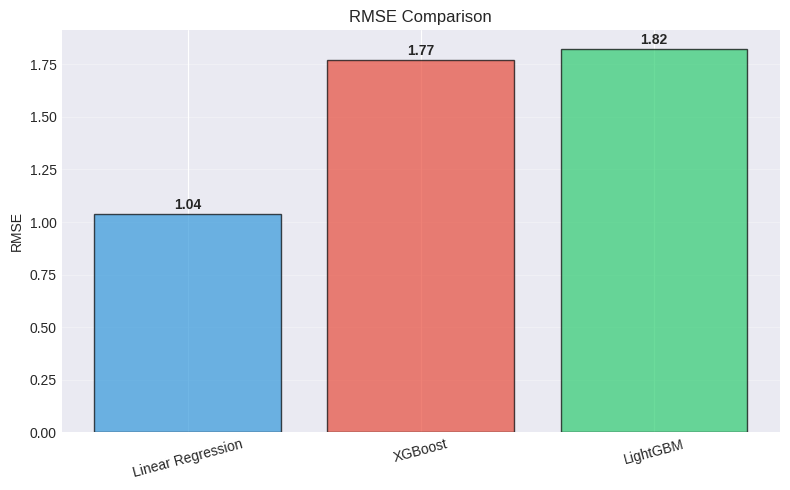

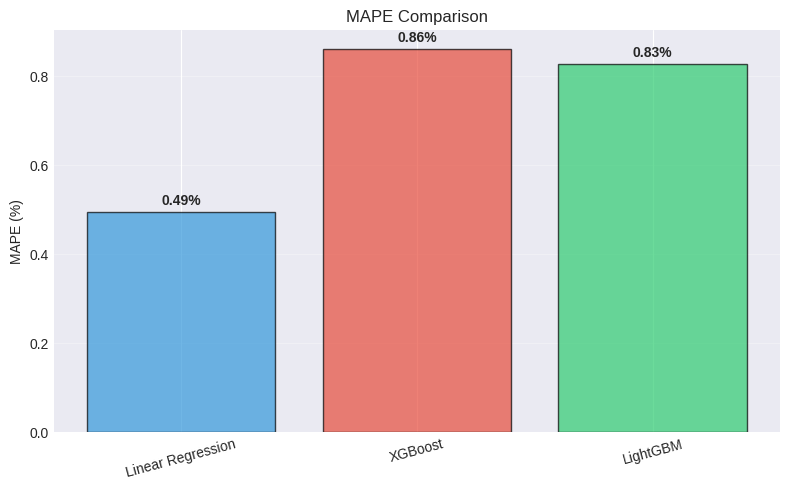

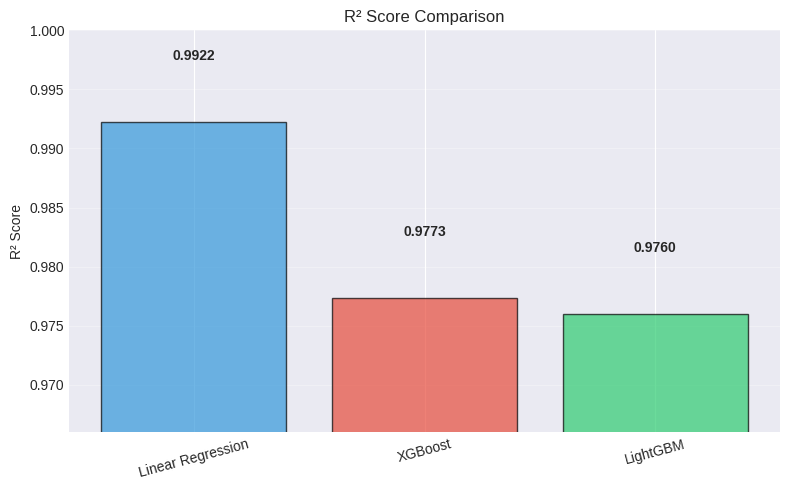

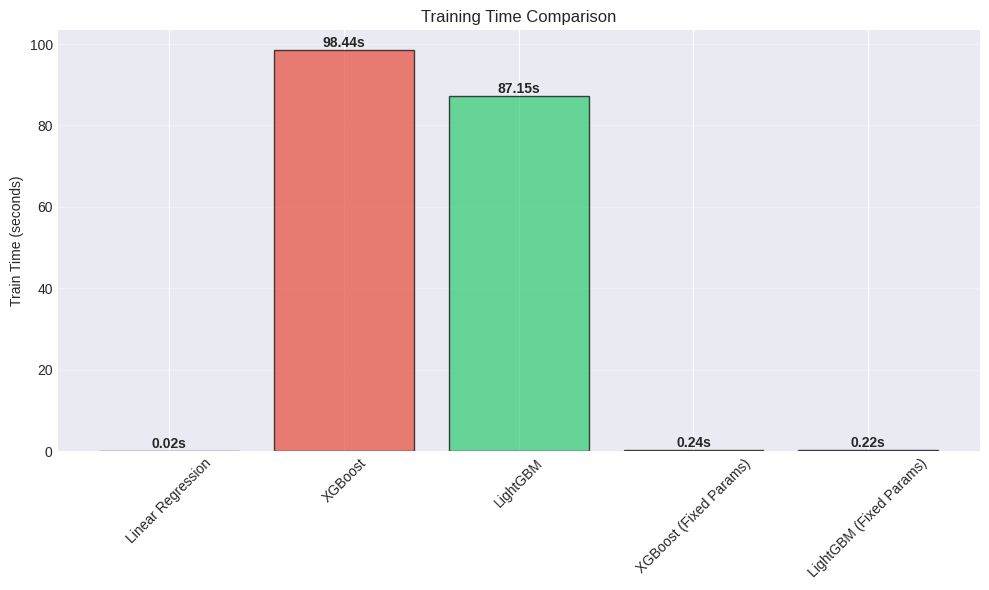

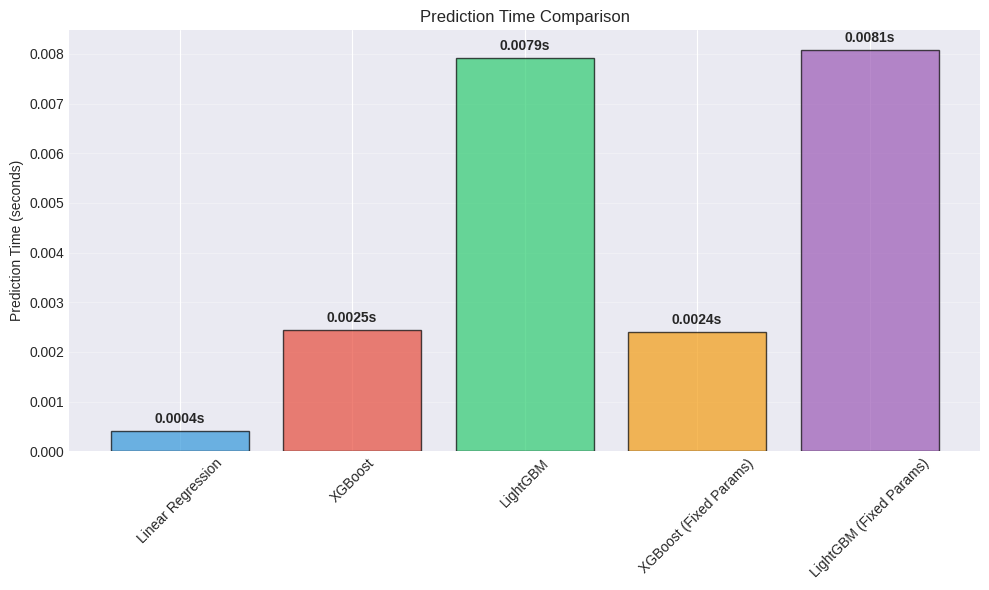

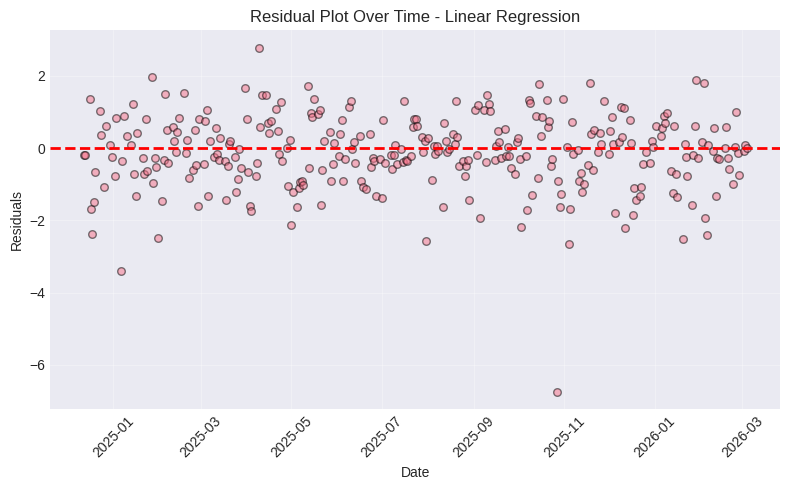

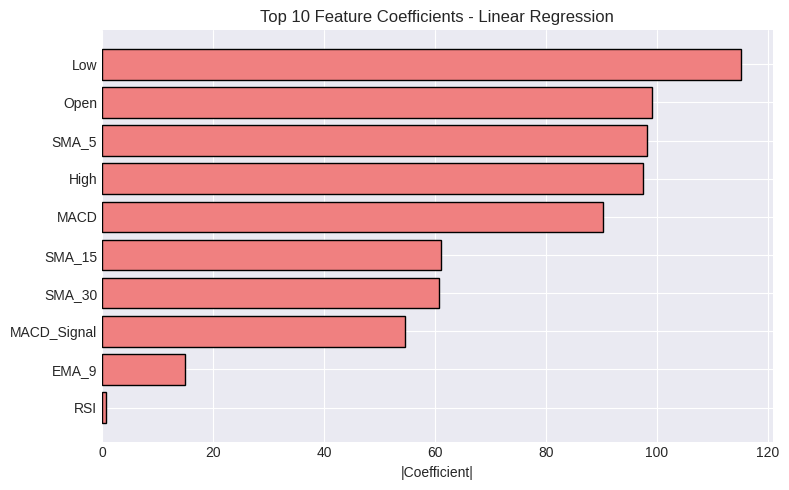

In [11]:
print("\n" + "="*80)
print("PERBANDINGAN HASIL MODEL")
print("="*80)

# Filter models to only include Linear Regression and the GridSearchCV results for boosting models
filtered_models = ['Linear Regression', 'XGBoost', 'LightGBM']

# Buat tabel perbandingan
comparison_df = pd.DataFrame({
    'Model': filtered_models,
    'RMSE': [results[m]['RMSE'] for m in filtered_models],
    'MAE': [results[m]['MAE'] for m in filtered_models],
    'MAPE (%)': [results[m]['MAPE'] for m in filtered_models],
    'R²': [results[m]['R2'] for m in filtered_models],
    'Train Time (s)': [results[m]['Train Time'] for m in filtered_models],
    'Prediction Time (s)': [results[m]['Prediction Time'] for m in filtered_models]
})

print("\n" + comparison_df.to_string(index=False))

# Tentukan model terbaik
best_model_name = comparison_df.loc[comparison_df['RMSE'].idxmin(), 'Model']
print(f"\nMODEL TERBAIK: {best_model_name}")
print(f"   (Berdasarkan RMSE terendah)")

# ============================================================================
# 7. VISUALISASI
# ============================================================================
print("\n[5] MEMBUAT VISUALISASI...")

# Ambil tanggal untuk data test
test_dates = df.loc[y_test.index, 'Date'].values

# Plot 1: Perbandingan Prediksi vs Aktual
plt.figure(figsize=(10, 6))
plt.plot(test_dates, y_test.values, label='Actual', linewidth=2, marker='o',
         markersize=3, alpha=0.7)
plt.plot(test_dates, results['Linear Regression']['predictions'], label='Linear Regression', linewidth=1.5,
         linestyle='--', alpha=0.8)
plt.plot(test_dates, results['XGBoost']['predictions'], label='XGBoost', linewidth=1.5,
         linestyle='--', alpha=0.8)
plt.plot(test_dates, results['LightGBM']['predictions'], label='LightGBM', linewidth=1.5,
         linestyle='--', alpha=0.8)
plt.xlabel('Date')
plt.ylabel('Price')
plt.title('Prediction vs Actual - All Models')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(f'{ticker}_prediction_vs_actual.eps', format='eps')
plt.show()

# Plot 2: Bar chart perbandingan RMSE
models_for_metrics = filtered_models # Use filtered models for plotting for RMSE, MAE, R2
plt.figure(figsize=(8, 5))
rmse_values = [results[m]['RMSE'] for m in models_for_metrics]
colors = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12', '#9b59b6'] # Added more colors for more models
bars = plt.bar(models_for_metrics, rmse_values, color=colors, alpha=0.7, edgecolor='black')
plt.ylabel('RMSE')
plt.title('RMSE Comparison')
plt.xticks(rotation=15)
for bar, val in zip(bars, rmse_values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{val:.2f}', ha='center', va='bottom', fontweight='bold')
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig(f'{ticker}_rmse_comparison.eps', format='eps')
plt.show()

# Plot 3: Bar chart perbandingan MAPE
plt.figure(figsize=(8, 5))
mape_values = [results[m]['MAPE'] for m in models_for_metrics]
bars = plt.bar(models_for_metrics, mape_values, color=colors, alpha=0.7, edgecolor='black')
plt.ylabel('MAPE (%)')
plt.title('MAPE Comparison')
plt.xticks(rotation=15)
for bar, val in zip(bars, mape_values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{val:.2f}%', ha='center', va='bottom', fontweight='bold')
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig(f'{ticker}_mape_comparison.eps', format='eps')
plt.show()

# Plot 4: Bar chart perbandingan R²
plt.figure(figsize=(8, 5))
r2_values = [results[m]['R2'] for m in models_for_metrics]
bars = plt.bar(models_for_metrics, r2_values, color=colors, alpha=0.7, edgecolor='black')
plt.ylabel('R² Score')
plt.title('R² Score Comparison')
plt.xticks(rotation=15)
plt.ylim([min(r2_values) - 0.01, 1.0])
for bar, val in zip(bars, r2_values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
             f'{val:.4f}', ha='center', va='bottom', fontweight='bold')
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig(f'{ticker}_r2_comparison.eps', format='eps')
plt.show()

# Plot 5: Bar chart perbandingan Runtime (Train Time)
models_for_time = list(results.keys()) # Use all models for time comparison
plt.figure(figsize=(10, 6))
train_times = [results[m]['Train Time'] for m in models_for_time]
bars = plt.bar(models_for_time, train_times, color=colors, alpha=0.7, edgecolor='black')
plt.ylabel('Train Time (seconds)')
plt.title('Training Time Comparison')
plt.xticks(rotation=45)
for bar, val in zip(bars, train_times):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{val:.2f}s', ha='center', va='bottom', fontweight='bold')
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig(f'{ticker}_train_time_comparison.eps', format='eps')
plt.show()

# Plot 6: Bar chart perbandingan Runtime (Prediction Time)
plt.figure(figsize=(10, 6))
prediction_times = [results[m]['Prediction Time'] for m in models_for_time]
bars = plt.bar(models_for_time, prediction_times, color=colors, alpha=0.7, edgecolor='black')
plt.ylabel('Prediction Time (seconds)')
plt.title('Prediction Time Comparison')
plt.xticks(rotation=45)
for bar, val in zip(bars, prediction_times):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.0001,
             f'{val:.4f}s', ha='center', va='bottom', fontweight='bold') # Use higher precision for small prediction times
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig(f'{ticker}_prediction_time_comparison.eps', format='eps')
plt.show()


# Plot 7: Residual plot untuk model terbaik
plt.figure(figsize=(8, 5))
best_predictions = results[best_model_name]['predictions']
residuals = y_test.values - best_predictions
plt.scatter(test_dates, residuals, alpha=0.5, edgecolors='black', s=30)
plt.axhline(y=0, color='r', linestyle='--', linewidth=2)
plt.xlabel('Date')
plt.ylabel('Residuals')
plt.title(f'Residual Plot Over Time - {best_model_name}')
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(f'{ticker}_residual_plot.eps', format='eps')
plt.show()

# Plot 8: Feature importance untuk model terbaik (jika applicable)
plt.figure(figsize=(8, 5))
if best_model_name in ['XGBoost', 'LightGBM']:
    best_model = results[best_model_name]['model']
    if hasattr(best_model, 'feature_importances_'):
        importances = best_model.feature_importances_
        indices = np.argsort(importances)[::-1][:10]  # Top 10 features
        plt.barh(range(len(indices)), importances[indices], color='skyblue',
                 edgecolor='black')
        plt.yticks(range(len(indices)), [feature_cols[i] for i in indices])
        plt.xlabel('Importance')
        plt.title(f'Top 10 Feature Importance - {best_model_name}')
        plt.gca().invert_yaxis()
else:
    # Untuk Linear Regression, tampilkan koefisien
    coefficients = np.abs(results['Linear Regression']['model'].coef_)
    indices = np.argsort(coefficients)[::-1][:10]
    plt.barh(range(len(indices)), coefficients[indices], color='lightcoral',
             edgecolor='black')
    plt.yticks(range(len(indices)), [feature_cols[i] for i in indices])
    plt.xlabel('|Coefficient|')
    plt.title('Top 10 Feature Coefficients - Linear Regression')
    plt.gca().invert_yaxis()

plt.tight_layout()
plt.savefig(f'{ticker}_feature_importance.eps', format='eps')
plt.show()

In [12]:
print("\n" + "="*80)
print("KESIMPULAN")
print("="*80)

print(f"""
Model Terbaik: {best_model_name}
   - RMSE: {results[best_model_name]['RMSE']:.4f}
   - MAPE: {results[best_model_name]['MAPE']:.4f}%
   - R²: {results[best_model_name]['R2']:.4f}
""")


KESIMPULAN

Model Terbaik: Linear Regression
   - RMSE: 1.0361
   - MAPE: 0.4938%
   - R²: 0.9922



In [13]:
import json

# Combine best hyperparameters into a dictionary
best_hyperparameters = {
    "XGBoost": best_xgb_params_from_grid,
    "LightGBM": best_lgb_params_from_grid
}

# Define the filename
filename = f"{ticker}_best_hyperparameters.txt"

# Write the hyperparameters to a text file
with open(filename, 'w') as f:
    f.write("Best Hyperparameters for Models:\n\n")
    for model_name, params in best_hyperparameters.items():
        f.write(f"--- {model_name} ---\n")
        for param, value in params.items():
            f.write(f"{param}: {value}\n")
        f.write("\n")

print(f"Best hyperparameters saved to {filename}")

Best hyperparameters saved to QCOM_best_hyperparameters.txt


In [14]:
from google.colab import drive
import os
import shutil

# 1. Mount Google Drive
drive.mount('/content/drive')

# 2. Define path for the specific ticker folder
target_dir = f'/content/drive/MyDrive/MLT/{ticker}'

# 3. Create directory if it doesn't exist
if not os.path.exists(target_dir):
    os.makedirs(target_dir)
    print(f"Folder created: {target_dir}")
else:
    print(f"Folder already exists: {target_dir}")

# 4. List of extensions to move
extensions = ['.eps', '.png', '.txt']

# 5. Move files from /content to target_dir
files_moved = 0
for file in os.listdir('/content'):
    if any(file.endswith(ext) for ext in extensions):
        shutil.move(os.path.join('/content', file), os.path.join(target_dir, file))
        files_moved += 1

print(f"Successfully moved {files_moved} files to {target_dir}")

Mounted at /content/drive
Folder already exists: /content/drive/MyDrive/MLT/QCOM
Successfully moved 16 files to /content/drive/MyDrive/MLT/QCOM
